# 教学案例：协同过滤 + 轻量 MLP 电影推荐（MovieLens 100K）

## 1. 这个知识点是什么？
推荐系统的目标是：**把合适的物品推荐给合适的用户**。在电影推荐中，我们常见两条思路：

- **协同过滤（Collaborative Filtering, CF）**：基于“相似用户/相似物品”的历史行为做推荐。
- **神经网络推荐（这里用轻量 MLP）**：学习用户和电影的低维表示（Embedding），再用小型多层感知机预测评分。

## 2. 为什么要设计这个程序？
这个教学案例有三个意义：

1. 让同学们理解推荐系统从“规则相似”到“可学习模型”的过渡；
2. 在同一数据集上比较两类方法的效果与适用场景；
3. 形成可复用的推荐建模流程：数据读取 → 特征编码 → 建模 → 评估 → Top-N 推荐。

## 3. 实验目标

- 使用 `u1.base` / `u1.test` 构建训练集与测试集；
- 实现一个**ItemCF（基于物品相似度）**推荐器；
- 实现一个**轻量 MLP（Embedding + 小网络）**评分预测器；
- 对比两者在 RMSE / MAE 上的表现，并输出示例 Top-N 推荐结果。

In [1]:
import os
import random
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 为了可复现性
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option('display.max_rows', 10)
pd.set_option('display.width', 120)

DATA_DIR = r"D:\xiangmu\j33-tuijian\data\ml-100k"
TRAIN_FILE = os.path.join(DATA_DIR, "u1.base")
TEST_FILE = os.path.join(DATA_DIR, "u1.test")

print("DATA_DIR:", DATA_DIR)
print("训练集文件存在:", os.path.exists(TRAIN_FILE))
print("测试集文件存在:", os.path.exists(TEST_FILE))

DATA_DIR: D:\xiangmu\j33-tuijian\data\ml-100k
训练集文件存在: True
测试集文件存在: True


In [2]:
# MovieLens 100K 格式：user_id \t item_id \t rating \t timestamp
cols = ["user_id", "item_id", "rating", "timestamp"]
train_df = pd.read_csv(TRAIN_FILE, sep="\t", names=cols)
test_df = pd.read_csv(TEST_FILE, sep="\t", names=cols)

print("train_df shape:", train_df.shape)
print("test_df shape:", test_df.shape)
print("\n训练集前5行：")
display(train_df.head())

n_users = int(max(train_df.user_id.max(), test_df.user_id.max()))
n_items = int(max(train_df.item_id.max(), test_df.item_id.max()))

print(f"用户数: {n_users}, 电影数: {n_items}")
print(f"训练评分数: {len(train_df)}, 测试评分数: {len(test_df)}")

train_df shape: (80000, 4)
test_df shape: (20000, 4)

训练集前5行：


,user_id,item_id,rating,timestamp
0,1,1,5,874965758
1,1,2,3,876893171
2,1,3,4,878542960
3,1,4,3,876893119
4,1,5,3,889751712


用户数: 943, 电影数: 1682
训练评分数: 80000, 测试评分数: 20000


In [3]:
# 一些必要的中间结果：数据分布与稀疏度
rating_desc = train_df["rating"].describe()
print("训练集评分分布描述：")
display(rating_desc)

user_activity = train_df.groupby("user_id")["rating"].count()
item_popularity = train_df.groupby("item_id")["rating"].count()

print("\n用户评分次数（前5个用户）：")
display(user_activity.head())
print("电影被评分次数（前5个电影）：")
display(item_popularity.head())

density = len(train_df) / (n_users * n_items)
print(f"\n用户-电影矩阵稀疏度: {1 - density:.4f}（越接近1表示越稀疏）")

训练集评分分布描述：


count    80000.000000
mean         3.528350
std          1.118565
min          1.000000
25%          3.000000
50%          4.000000
75%          4.000000
max          5.000000
Name: rating, dtype: float64


用户评分次数（前5个用户）：


user_id
1    135
2     40
3     28
4     14
5     91
Name: rating, dtype: int64

电影被评分次数（前5个电影）：


item_id
1    383
2    105
3     75
4    171
5     69
Name: rating, dtype: int64


用户-电影矩阵稀疏度: 0.9496（越接近1表示越稀疏）


## 4. 协同过滤（ItemCF）

核心思想：

- 若两部电影被很多相似用户共同高分，它们可能“相似”；
- 对目标用户预测某电影评分时，参考该用户已看电影与目标电影的相似度加权。

这里采用余弦相似度并保留每个物品的 Top-K 邻居。

In [4]:
# 构造用户-电影评分矩阵（行: user, 列: item）
rows = train_df["user_id"].values - 1
cols_i = train_df["item_id"].values - 1
vals = train_df["rating"].values.astype(np.float32)

R = csr_matrix((vals, (rows, cols_i)), shape=(n_users, n_items))
print("评分矩阵形状:", R.shape)
print("非零评分数:", R.nnz)

# 计算物品-物品相似度（余弦）
item_sim = cosine_similarity(R.T, dense_output=False)
print("item_sim 形状:", item_sim.shape)

# 展示某一电影（示例：item_id=1）最相似的前10个电影id（不含自己）
sample_item = 1
sim_vec = item_sim[sample_item - 1].toarray().ravel()
rank_idx = np.argsort(-sim_vec)
rank_idx = rank_idx[rank_idx != (sample_item - 1)][:10]
print(f"与电影 {sample_item} 最相似的10个电影id:", (rank_idx + 1).tolist())

评分矩阵形状: (943, 1682)
非零评分数: 80000
item_sim 形状: (1682, 1682)
与电影 1 最相似的10个电影id: [50, 181, 121, 117, 405, 222, 237, 151, 118, 7]


In [5]:
TOP_K = 30
GLOBAL_MEAN = train_df["rating"].mean()

def predict_itemcf(user_id: int, item_id: int, top_k: int = TOP_K) -> float:
    u = user_id - 1
    i = item_id - 1

    user_row = R.getrow(u)
    rated_items = user_row.indices
    rated_scores = user_row.data

    if len(rated_items) == 0:
        return float(GLOBAL_MEAN)

    sims = item_sim[i, rated_items].toarray().ravel()
    if len(sims) == 0 or np.all(sims == 0):
        return float(np.mean(rated_scores))

    top_idx = np.argsort(-np.abs(sims))[:top_k]
    top_sims = sims[top_idx]
    top_scores = rated_scores[top_idx]

    denom = np.sum(np.abs(top_sims))
    if denom < 1e-8:
        return float(np.mean(rated_scores))

    pred = np.dot(top_sims, top_scores) / denom
    return float(np.clip(pred, 1.0, 5.0))

# 在测试集上评估 ItemCF（仅使用出现过的 user/item）
cf_preds = []
cf_true = []
for row in test_df.itertuples(index=False):
    cf_preds.append(predict_itemcf(int(row.user_id), int(row.item_id)))
    cf_true.append(float(row.rating))

cf_rmse = mean_squared_error(cf_true, cf_preds) ** 0.5
cf_mae = mean_absolute_error(cf_true, cf_preds)

print("=== ItemCF 结果解读 ===")
print(f"RMSE = {cf_rmse:.4f}，MAE = {cf_mae:.4f}")
print("说明：RMSE/MAE 越小越好，表示预测评分更接近真实评分。")
print("一般来说，RMSE 对较大误差更敏感；MAE 更直观反映平均误差。")

print("\n前10条测试样本：")
print("- true: 真实评分")
print("- pred_itemcf: ItemCF 预测评分")
preview_df = pd.DataFrame({
    "true": cf_true[:10],
    "pred_itemcf": np.round(cf_preds[:10], 3)
})
display(preview_df)

=== ItemCF 结果解读 ===
RMSE = 1.0035，MAE = 0.7836
说明：RMSE/MAE 越小越好，表示预测评分更接近真实评分。
一般来说，RMSE 对较大误差更敏感；MAE 更直观反映平均误差。

前10条测试样本：
- true: 真实评分
- pred_itemcf: ItemCF 预测评分


,true,pred_itemcf
0,5.0,4.308
1,3.0,4.389
2,5.0,4.263
3,5.0,4.410
4,3.0,3.864
5,4.0,4.146
6,4.0,4.142
7,3.0,4.195
8,2.0,3.729
9,3.0,4.224


In [6]:
def recommend_itemcf_for_user(user_id: int, top_n: int = 10):
    u = user_id - 1
    seen_items = set(R.getrow(u).indices + 1)

    candidates = [i for i in range(1, n_items + 1) if i not in seen_items]
    scored = []
    for item_id in candidates:
        scored.append((item_id, predict_itemcf(user_id, item_id)))

    scored.sort(key=lambda x: x[1], reverse=True)
    return scored[:top_n]

sample_user = 10
topn_cf = recommend_itemcf_for_user(sample_user, top_n=10)
print(f"=== 用户 {sample_user} 的 ItemCF Top-10 推荐 ===")
print("解读：")
print("- item_id: 电影编号（可去 u.item 里查电影名称）")
print("- pred_rating: 预测评分，越高代表系统越推荐")
print("- 这里只展示该用户未看过电影中的前10名")
display(pd.DataFrame(topn_cf, columns=["item_id", "pred_rating"]))

=== 用户 10 的 ItemCF Top-10 推荐 ===
解读：
- item_id: 电影编号（可去 u.item 里查电影名称）
- pred_rating: 预测评分，越高代表系统越推荐
- 这里只展示该用户未看过电影中的前10名


,item_id,pred_rating
0,1653,4.694683
1,646,4.645091
2,1500,4.635235
3,1618,4.604572
4,657,4.589963
5,524,4.588534
6,603,4.583239
7,135,4.577446
8,641,4.572800
9,1358,4.566875


## 5. 轻量 MLP 推荐模型（Embedding + MLP）

思路：

1. 用 `user_id` 和 `item_id` 的 embedding 学习用户、电影的隐向量；
2. 将两个隐向量拼接后输入小型 MLP；
3. 输出预测评分，并与真实评分做回归训练（MSE）。

> 这是神经协同过滤（Neural CF）的一种轻量实现。

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

class RatingDataset(Dataset):
    def __init__(self, df):
        self.users = torch.tensor(df["user_id"].values - 1, dtype=torch.long)
        self.items = torch.tensor(df["item_id"].values - 1, dtype=torch.long)
        self.ratings = torch.tensor(df["rating"].values, dtype=torch.float32)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx]

train_ds = RatingDataset(train_df)
test_ds = RatingDataset(test_df)

train_loader = DataLoader(train_ds, batch_size=1024, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=2048, shuffle=False)

print("train batches:", len(train_loader), "test batches:", len(test_loader))

Using device: cuda
train batches: 79 test batches: 10


In [8]:
class LightMLPRec(nn.Module):
    def __init__(self, num_users, num_items, emb_dim=32, hidden_dim=64, dropout=0.1):
        super().__init__()
        self.user_emb = nn.Embedding(num_users, emb_dim)
        self.item_emb = nn.Embedding(num_items, emb_dim)

        self.mlp = nn.Sequential(
            nn.Linear(emb_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, user_idx, item_idx):
        u = self.user_emb(user_idx)
        i = self.item_emb(item_idx)
        x = torch.cat([u, i], dim=1)
        out = self.mlp(x).squeeze(1)
        return out

model = LightMLPRec(n_users, n_items, emb_dim=32, hidden_dim=64, dropout=0.1).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

print(model)

LightMLPRec(
  (user_emb): Embedding(943, 32)
  (item_emb): Embedding(1682, 32)
  (mlp): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [9]:
def evaluate_mlp(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for users, items, ratings in loader:
            users = users.to(DEVICE)
            items = items.to(DEVICE)
            ratings = ratings.to(DEVICE)
            out = model(users, items)
            out = torch.clamp(out, 1.0, 5.0)
            preds.append(out.cpu().numpy())
            trues.append(ratings.cpu().numpy())

    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    rmse = np.sqrt(mean_squared_error(trues, preds))
    mae = mean_absolute_error(trues, preds)
    return rmse, mae, preds, trues

EPOCHS = 8
for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0

    for users, items, ratings in train_loader:
        users = users.to(DEVICE)
        items = items.to(DEVICE)
        ratings = ratings.to(DEVICE)

        optimizer.zero_grad()
        out = model(users, items)
        loss = criterion(out, ratings)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * len(ratings)

    train_mse = running_loss / len(train_ds)
    test_rmse, test_mae, _, _ = evaluate_mlp(model, test_loader)
    print(f"Epoch {epoch:02d} | train_MSE={train_mse:.4f} | test_RMSE={test_rmse:.4f} | test_MAE={test_mae:.4f}")

Epoch 01 | train_MSE=6.5961 | test_RMSE=1.2219 | test_MAE=0.9925
Epoch 02 | train_MSE=1.3675 | test_RMSE=1.1498 | test_MAE=0.9389
Epoch 03 | train_MSE=1.2480 | test_RMSE=1.1118 | test_MAE=0.9069
Epoch 04 | train_MSE=1.1675 | test_RMSE=1.0839 | test_MAE=0.8807
Epoch 05 | train_MSE=1.1093 | test_RMSE=1.0623 | test_MAE=0.8589
Epoch 06 | train_MSE=1.0640 | test_RMSE=1.0449 | test_MAE=0.8454
Epoch 07 | train_MSE=1.0303 | test_RMSE=1.0308 | test_MAE=0.8312
Epoch 08 | train_MSE=1.0054 | test_RMSE=1.0195 | test_MAE=0.8193


In [10]:
mlp_rmse, mlp_mae, mlp_preds, mlp_true = evaluate_mlp(model, test_loader)
print("=== Light MLP 结果解读 ===")
print(f"RMSE = {mlp_rmse:.4f}，MAE = {mlp_mae:.4f}")
print("说明：该模型通过 Embedding + 小型MLP 学习用户与电影的非线性交互。")
print("如果 RMSE/MAE 低于 ItemCF，说明在该划分下神经模型拟合得更好。")

print("\n前10条测试样本：")
print("- true: 真实评分")
print("- pred_mlp: MLP 预测评分")
preview_mlp = pd.DataFrame({
    "true": mlp_true[:10],
    "pred_mlp": np.round(mlp_preds[:10], 3)
})
display(preview_mlp)

def recommend_mlp_for_user(user_id: int, top_n: int = 10):
    user_idx = user_id - 1
    seen_items = set(R.getrow(user_idx).indices)
    candidates = np.array([i for i in range(n_items) if i not in seen_items], dtype=np.int64)

    users = torch.tensor(np.full_like(candidates, user_idx), dtype=torch.long, device=DEVICE)
    items = torch.tensor(candidates, dtype=torch.long, device=DEVICE)

    model.eval()
    with torch.no_grad():
        scores = model(users, items)
        scores = torch.clamp(scores, 1.0, 5.0).cpu().numpy()

    rank = np.argsort(-scores)[:top_n]
    rec_items = candidates[rank] + 1
    rec_scores = scores[rank]

    return pd.DataFrame({"item_id": rec_items, "pred_rating": np.round(rec_scores, 3)})

sample_user = 10
topn_mlp = recommend_mlp_for_user(sample_user, top_n=10)
print(f"\n=== 用户 {sample_user} 的 MLP Top-10 推荐 ===")
print("解读：pred_rating 越高，表示模型认为该用户越可能喜欢该电影。")
display(topn_mlp)

=== Light MLP 结果解读 ===
RMSE = 1.0195，MAE = 0.8193
说明：该模型通过 Embedding + 小型MLP 学习用户与电影的非线性交互。
如果 RMSE/MAE 低于 ItemCF，说明在该划分下神经模型拟合得更好。

前10条测试样本：
- true: 真实评分
- pred_mlp: MLP 预测评分


,true,pred_mlp
0,5.0,3.428
1,3.0,4.303
2,5.0,4.688
3,5.0,3.990
4,3.0,3.627
5,4.0,3.902
6,4.0,3.901
7,3.0,3.639
8,2.0,3.492
9,3.0,3.597



=== 用户 10 的 MLP Top-10 推荐 ===
解读：pred_rating 越高，表示模型认为该用户越可能喜欢该电影。


,item_id,pred_rating
0,285,4.928
1,515,4.864
2,98,4.862
3,64,4.766
4,915,4.752
5,483,4.742
6,427,4.731
7,187,4.709
8,22,4.648
9,173,4.629


In [11]:
compare_df = pd.DataFrame([
    {"model": "ItemCF", "RMSE": cf_rmse, "MAE": cf_mae},
    {"model": "Light MLP", "RMSE": mlp_rmse, "MAE": mlp_mae}
])

print("=== 模型效果总对比（数值越小越好）===")
print("- RMSE：对大误差更敏感")
print("- MAE：平均绝对误差，更容易直观理解")
print("- 课堂建议：不要只看一个指标，可结合 Top-N 结果一起分析")
display(compare_df.sort_values("RMSE"))

=== 模型效果总对比（数值越小越好）===
- RMSE：对大误差更敏感
- MAE：平均绝对误差，更容易直观理解
- 课堂建议：不要只看一个指标，可结合 Top-N 结果一起分析


,model,RMSE,MAE
0,ItemCF,1.003456,0.783638
1,Light MLP,1.019466,0.819332


## 6.1 核心输出 1 + 2：实验报告级可视化与个性化结果

本节提供与你给的模板相同风格的三类结果中的前两类：
1. **模型性能评估指标（Top-K 排序指标 + 耗时）**：`Precision@10`、`Recall@10`、`NDCG@10`、平均推荐耗时；
2. **分用户 / 分电影补充分析**：年龄分群 Precision@10、电影类型 Recall@10；
3. **个性化 Top10 推荐列表**：包含电影名、类型、预测评分和“匹配理由”。

> 评价口径：测试集评分 `>=4` 视为“喜欢”。

In [12]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path
import warnings

# ====== 1. 强制设置中文字体 ======
# 手动指定系统中存在的中文字体路径（Windows通用）
font_paths = [
    "C:/Windows/Fonts/msyh.ttc",  # 微软雅黑
    "C:/Windows/Fonts/simhei.ttf", # 黑体
    "C:/Windows/Fonts/simsun.ttc"  # 宋体
]
# 选择第一个可用的字体
font_path = None
for fp in font_paths:
    if Path(fp).exists():
        font_path = fp
        break

if font_path:
    font_prop = fm.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = font_prop.get_name()
else:
    # 备选方案：使用默认支持中文的字体名称
    plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示问题

# ====== 2. 隐藏字体警告 ======
warnings.filterwarnings('ignore', category=UserWarning, message="Glyph * missing from current font")

=== 核心输出1：整体推荐效果指标（数值越大越好，耗时越小越好）===


,model,Precision@10,Recall@10,NDCG@10,平均推荐耗时（ms/用户）
0,纯协同过滤（ItemCF）,0.036000,0.006646,0.081829,234.178749
1,纯 MLP,0.125333,0.046304,0.357372,0.959243
2,混合模型（CF+MLP）,0.131000,0.042686,0.306097,237.463223


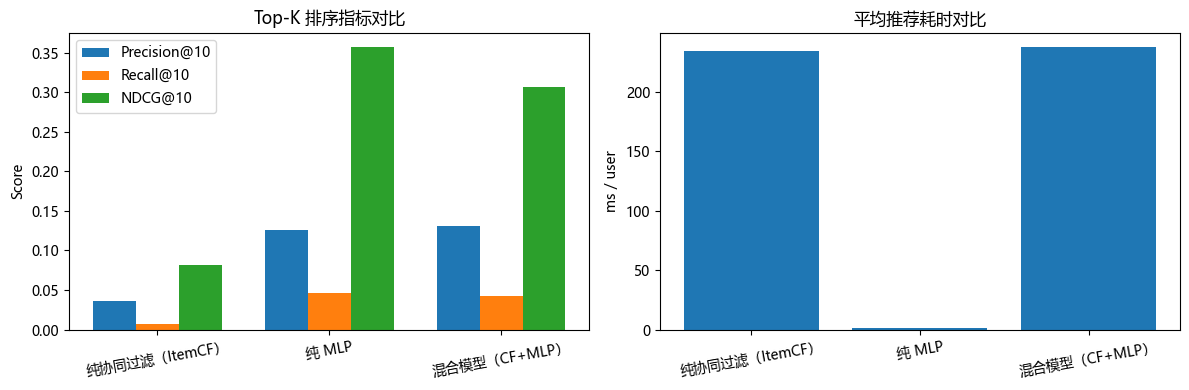


=== 补充分析：不同年龄段用户 Precision@10 ===


,age_group,CF+MLP,纯CF
0,18以下,0.050000,0.000000
1,18-25,0.126087,0.026087
2,26-35,0.134000,0.033000
3,36-45,0.122581,0.024194
4,45+,0.154237,0.071186


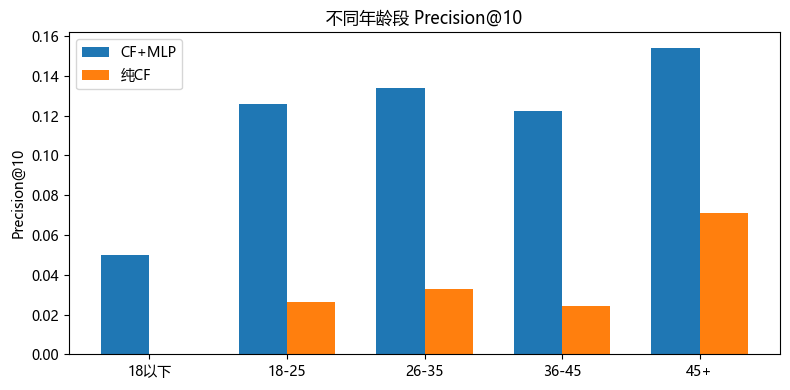


=== 补充分析：不同电影类型 Recall@10（混合模型）===


,电影类型,Recall@10,样本基数
10,Film-Noir,0.137143,175
17,War,0.108420,867
6,Crime,0.086037,709
13,Mystery,0.080899,445
8,Drama,0.067213,3541
7,Documentary,0.057471,87
2,Adventure,0.056311,1030
1,Action,0.055110,1996
16,Thriller,0.052299,1740
15,Sci-Fi,0.050645,1086


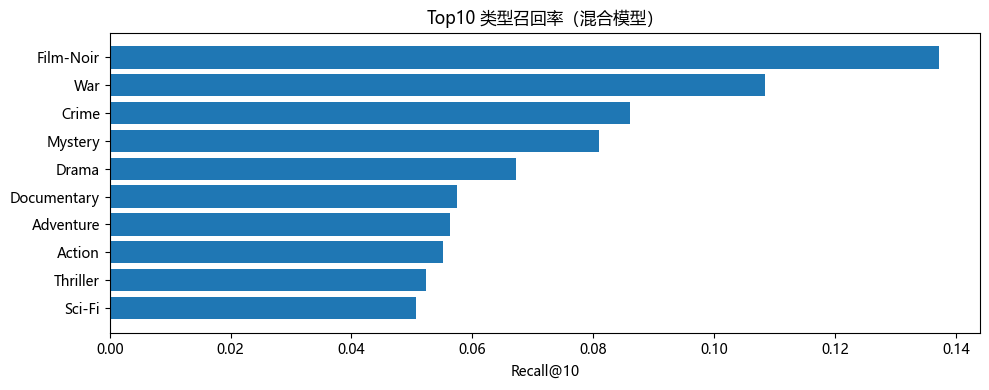


=== 用户 123 的历史高评分电影（评分>=4）===


,item_id,title,rating,genres
0,9,Dead Man Walking (1995),5,Drama
21,514,Annie Hall (1977),5,Comedy/Romance
20,504,Bonnie and Clyde (1967),5,Crime/Drama
16,435,Butch Cassidy and the Sundance Kid (1969),5,Action/Comedy/Western
15,432,Fantasia (1940),5,Animation/Children's/Musical
9,197,"Graduate, The (1967)",5,Drama/Romance
10,242,Kolya (1996),5,Comedy
1,14,"Postino, Il (1994)",5,Drama/Romance
12,286,"English Patient, The (1996)",5,Drama/Romance/War
14,321,Mother (1996),4,Comedy


=== 用户 123 的 CF+MLP 混合模型推荐 Top10 ===


,排名,电影名称,类型,推荐评分（混合）,匹配理由
0,1,Raiders of the Lost Ark (1981),Action/Adventure,4.570,"与《Silence of the Lambs, The (1991)》相似 + MLP打分=..."
1,2,Grace of My Heart (1996),Comedy/Drama,4.448,"与《Godfather: Part II, The (1974)》相似 + 匹配偏好类型：D..."
2,3,To Kill a Mockingbird (1962),Drama,4.438,"与《Silence of the Lambs, The (1991)》相似 + 匹配偏好类型..."
3,4,Laura (1944),Crime/Film-Noir/Mystery,4.425,"与《Manchurian Candidate, The (1962)》相似 + MLP打分=..."
4,5,Good Will Hunting (1997),Drama,4.412,"与《English Patient, The (1996)》相似 + 匹配偏好类型：Dram..."
5,6,Ran (1985),Drama/War,4.411,与《Vertigo (1958)》相似 + 匹配偏好类型：Drama/Comedy + ML...
6,7,Secrets & Lies (1996),Drama,4.385,"与《Postino, Il (1994)》相似 + 匹配偏好类型：Drama/Comedy ..."
7,8,Titanic (1997),Action/Drama/Romance,4.372,与《Liar Liar (1997)》相似 + 匹配偏好类型：Drama/Comedy + ...
8,9,Shine (1996),Drama/Romance,4.360,与《Psycho (1960)》相似 + 匹配偏好类型：Drama/Comedy + MLP...
9,10,"Empire Strikes Back, The (1980)",Action/Adventure/Drama/Romance/Sci-Fi/War,4.356,"与《Silence of the Lambs, The (1991)》相似 + 匹配偏好类型..."


In [13]:
# ---------- 核心输出1 + 核心输出2：量化指标、分群分析、个性化Top10 ----------
import time
import matplotlib.pyplot as plt

# 1) 读取用户与电影元数据
USER_FILE = os.path.join(DATA_DIR, "u.user")
ITEM_FILE = os.path.join(DATA_DIR, "u.item")
GENRE_FILE = os.path.join(DATA_DIR, "u.genre")

user_cols = ["user_id", "age", "gender", "occupation", "zip_code"]
user_meta = pd.read_csv(USER_FILE, sep="|", names=user_cols, engine="python")

genre_df = pd.read_csv(GENRE_FILE, sep="|", names=["genre", "gid"], engine="python")
genre_df = genre_df[pd.to_numeric(genre_df["gid"], errors="coerce").notna()].copy()
genre_df["gid"] = genre_df["gid"].astype(int)
genre_names = genre_df.sort_values("gid")["genre"].tolist()

item_cols = ["item_id", "title", "release_date", "video_release_date", "imdb_url"] + genre_names
item_meta = pd.read_csv(
    ITEM_FILE,
    sep="|",
    names=item_cols,
    encoding="latin-1",
    engine="python"
 )

item_title_map = dict(zip(item_meta["item_id"], item_meta["title"]))

def get_item_genres(item_id: int):
    row = item_meta.loc[item_meta["item_id"] == item_id, genre_names]
    if row.empty:
        return []
    flags = row.iloc[0].values.astype(int)
    return [genre_names[i] for i, v in enumerate(flags) if v == 1]

# 2) 准备评估所需映射
train_seen_map = train_df.groupby("user_id")["item_id"].apply(set).to_dict()
test_pos_map = test_df[test_df["rating"] >= 4].groupby("user_id")["item_id"].apply(set).to_dict()
test_user_ids = sorted(test_df["user_id"].unique().tolist())

def minmax_scale(arr: np.ndarray):
    arr = np.asarray(arr, dtype=np.float32)
    if arr.size == 0:
        return arr
    lo, hi = float(np.min(arr)), float(np.max(arr))
    if hi - lo < 1e-12:
        return np.zeros_like(arr) + 0.5
    return (arr - lo) / (hi - lo)

def ndcg_at_k(binary_rel, k=10):
    rel = np.asarray(binary_rel[:k], dtype=np.float32)
    if rel.size == 0:
        return 0.0
    discounts = 1.0 / np.log2(np.arange(2, rel.size + 2))
    dcg = float(np.sum(rel * discounts))
    ideal = np.sort(rel)[::-1]
    idcg = float(np.sum(ideal * discounts))
    return 0.0 if idcg < 1e-12 else dcg / idcg

def score_candidates_for_user(user_id: int, candidate_items: np.ndarray, model_type="cf", alpha=0.5):
    # candidate_items 为 1-based item_id 数组
    if model_type == "cf":
        scores_cf = np.array([predict_itemcf(user_id, int(it)) for it in candidate_items], dtype=np.float32)
        return scores_cf

    if model_type == "mlp":
        user_idx = user_id - 1
        with torch.no_grad():
            users = torch.full((len(candidate_items),), user_idx, dtype=torch.long, device=DEVICE)
            items = torch.tensor(candidate_items - 1, dtype=torch.long, device=DEVICE)
            scores_mlp = model(users, items)
            scores_mlp = torch.clamp(scores_mlp, 1.0, 5.0).cpu().numpy().astype(np.float32)
        return scores_mlp

    if model_type == "hybrid":
        scores_cf = np.array([predict_itemcf(user_id, int(it)) for it in candidate_items], dtype=np.float32)
        user_idx = user_id - 1
        with torch.no_grad():
            users = torch.full((len(candidate_items),), user_idx, dtype=torch.long, device=DEVICE)
            items = torch.tensor(candidate_items - 1, dtype=torch.long, device=DEVICE)
            scores_mlp = model(users, items)
            scores_mlp = torch.clamp(scores_mlp, 1.0, 5.0).cpu().numpy().astype(np.float32)

        s_cf = minmax_scale(scores_cf)
        s_mlp = minmax_scale(scores_mlp)
        return (alpha * s_cf + (1 - alpha) * s_mlp).astype(np.float32)

    raise ValueError(f"unknown model_type: {model_type}")

def evaluate_topk_model(model_type="cf", top_k=10, alpha=0.5, user_ids=None):
    if user_ids is None:
        user_ids = test_user_ids

    rows = []
    rec_records = []
    t0 = time.perf_counter()

    for uid in user_ids:
        pos_items = test_pos_map.get(uid, set())
        if len(pos_items) == 0:
            continue

        seen_items = train_seen_map.get(uid, set())
        candidates = np.array([i for i in range(1, n_items + 1) if i not in seen_items], dtype=np.int64)
        if candidates.size == 0:
            continue

        scores = score_candidates_for_user(uid, candidates, model_type=model_type, alpha=alpha)
        rank_idx = np.argsort(-scores)[:top_k]
        top_items = candidates[rank_idx]
        top_scores = scores[rank_idx]

        hits = np.array([1 if item in pos_items else 0 for item in top_items], dtype=np.float32)
        precision = float(np.mean(hits))
        recall = float(np.sum(hits) / max(len(pos_items), 1))
        ndcg = float(ndcg_at_k(hits, k=top_k))

        rows.append({
            "user_id": uid,
            f"Precision@{top_k}": precision,
            f"Recall@{top_k}": recall,
            f"NDCG@{top_k}": ndcg
        })

        rec_records.append({
            "user_id": uid,
            "top_items": top_items.tolist(),
            "top_scores": top_scores.tolist(),
            "pos_items": pos_items
        })

    elapsed = (time.perf_counter() - t0) * 1000.0
    avg_latency = elapsed / max(len(rows), 1)

    detail_df = pd.DataFrame(rows)
    rec_df = pd.DataFrame(rec_records)

    if detail_df.empty:
        summary = {
            "model": model_type,
            f"Precision@{top_k}": 0.0,
            f"Recall@{top_k}": 0.0,
            f"NDCG@{top_k}": 0.0,
            "avg_latency_ms_per_user": avg_latency
        }
    else:
        summary = {
            "model": model_type,
            f"Precision@{top_k}": float(detail_df[f"Precision@{top_k}"].mean()),
            f"Recall@{top_k}": float(detail_df[f"Recall@{top_k}"].mean()),
            f"NDCG@{top_k}": float(detail_df[f"NDCG@{top_k}"].mean()),
            "avg_latency_ms_per_user": avg_latency
        }

    return summary, detail_df, rec_df

# 可调参数：若机器较慢，可设置为 200~300；若要完整评估可设为 None
EVAL_USER_LIMIT = 300
eval_users = test_user_ids if EVAL_USER_LIMIT is None else test_user_ids[:EVAL_USER_LIMIT]

top_k = 10
alpha = 0.5  # CF 与 MLP 融合权重

cf_summary, cf_user_metrics, cf_recs = evaluate_topk_model("cf", top_k=top_k, alpha=alpha, user_ids=eval_users)
mlp_summary, mlp_user_metrics, mlp_recs = evaluate_topk_model("mlp", top_k=top_k, alpha=alpha, user_ids=eval_users)
hyb_summary, hyb_user_metrics, hyb_recs = evaluate_topk_model("hybrid", top_k=top_k, alpha=alpha, user_ids=eval_users)

model_name_map = {
    "cf": "纯协同过滤（ItemCF）",
    "mlp": "纯 MLP",
    "hybrid": "混合模型（CF+MLP）"
}

metrics_table = pd.DataFrame([cf_summary, mlp_summary, hyb_summary])
metrics_table["model"] = metrics_table["model"].map(model_name_map)
metrics_table = metrics_table.rename(columns={
    f"Precision@{top_k}": f"Precision@{top_k}",
    f"Recall@{top_k}": f"Recall@{top_k}",
    f"NDCG@{top_k}": f"NDCG@{top_k}",
    "avg_latency_ms_per_user": "平均推荐耗时（ms/用户）"
})

print("=== 核心输出1：整体推荐效果指标（数值越大越好，耗时越小越好）===")
display(metrics_table)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(metrics_table))

axes[0].bar(x - 0.25, metrics_table[f"Precision@{top_k}"], width=0.25, label=f"Precision@{top_k}")
axes[0].bar(x, metrics_table[f"Recall@{top_k}"], width=0.25, label=f"Recall@{top_k}")
axes[0].bar(x + 0.25, metrics_table[f"NDCG@{top_k}"], width=0.25, label=f"NDCG@{top_k}")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_table["model"], rotation=10)
axes[0].set_title("Top-K 排序指标对比")
axes[0].set_ylabel("Score")
axes[0].legend()

axes[1].bar(metrics_table["model"], metrics_table["平均推荐耗时（ms/用户）"])
axes[1].set_title("平均推荐耗时对比")
axes[1].set_ylabel("ms / user")
axes[1].tick_params(axis="x", rotation=10)

plt.tight_layout()
plt.show()

# ---------- 分用户补充分析：不同年龄段 Precision@10 ----------
age_bins = [0, 17, 25, 35, 45, 120]
age_labels = ["18以下", "18-25", "26-35", "36-45", "45+"]
user_meta["age_group"] = pd.cut(user_meta["age"], bins=age_bins, labels=age_labels, include_lowest=True)

cf_age = cf_user_metrics.merge(user_meta[["user_id", "age_group"]], on="user_id", how="left")
hyb_age = hyb_user_metrics.merge(user_meta[["user_id", "age_group"]], on="user_id", how="left")

cf_age_precision = cf_age.groupby("age_group", observed=False)[f"Precision@{top_k}"].mean().rename("纯CF")
hyb_age_precision = hyb_age.groupby("age_group", observed=False)[f"Precision@{top_k}"].mean().rename("CF+MLP")
age_precision_table = pd.concat([hyb_age_precision, cf_age_precision], axis=1).reset_index()

print("\n=== 补充分析：不同年龄段用户 Precision@10 ===")
display(age_precision_table)

fig, ax = plt.subplots(figsize=(8, 4))
x_age = np.arange(len(age_precision_table))
w = 0.35
ax.bar(x_age - w/2, age_precision_table["CF+MLP"], width=w, label="CF+MLP")
ax.bar(x_age + w/2, age_precision_table["纯CF"], width=w, label="纯CF")
ax.set_xticks(x_age)
ax.set_xticklabels(age_precision_table["age_group"])
ax.set_ylabel(f"Precision@{top_k}")
ax.set_title("不同年龄段 Precision@10")
ax.legend()
plt.tight_layout()
plt.show()

# ---------- 分电影补充分析：不同类型电影 Recall@10（基于混合模型） ----------
genre_hit = {g: 0 for g in genre_names}
genre_total = {g: 0 for g in genre_names}

for rec_row in hyb_recs.itertuples(index=False):
    pos_items = rec_row.pos_items
    top_items = rec_row.top_items

    # 统计该用户喜欢电影（测试集评分>=4）在各类型上的总量
    for it in pos_items:
        gs = get_item_genres(int(it))
        for g in gs:
            genre_total[g] += 1

    # 统计命中到TopK的喜欢电影在各类型上的命中量
    hit_items = set(top_items).intersection(set(pos_items))
    for it in hit_items:
        gs = get_item_genres(int(it))
        for g in gs:
            genre_hit[g] += 1

genre_recall_rows = []
for g in genre_names:
    total = genre_total[g]
    rec = genre_hit[g] / total if total > 0 else 0.0
    genre_recall_rows.append({"电影类型": g, f"Recall@{top_k}": rec, "样本基数": total})

genre_recall_table = pd.DataFrame(genre_recall_rows).sort_values(f"Recall@{top_k}", ascending=False)
print("\n=== 补充分析：不同电影类型 Recall@10（混合模型）===")
display(genre_recall_table.head(10))

plt.figure(figsize=(10, 4))
top_genres_plot = genre_recall_table.head(10).sort_values(f"Recall@{top_k}")
plt.barh(top_genres_plot["电影类型"], top_genres_plot[f"Recall@{top_k}"])
plt.xlabel(f"Recall@{top_k}")
plt.title("Top10 类型召回率（混合模型）")
plt.tight_layout()
plt.show()

# ---------- 核心输出2：个性化推荐列表（含电影名与匹配理由） ----------
focus_user = 123 if 123 in train_seen_map else int(eval_users[0])

history_df = train_df[(train_df["user_id"] == focus_user) & (train_df["rating"] >= 4)].copy()
history_df = history_df.merge(item_meta[["item_id", "title"]], on="item_id", how="left")
history_df["genres"] = history_df["item_id"].apply(lambda x: "/".join(get_item_genres(int(x))))
history_df = history_df.sort_values("rating", ascending=False)[["item_id", "title", "rating", "genres"]].head(10)

# 用户偏好类型（基于高评分历史）
pref_genre_count = {}
for it in history_df["item_id"].tolist():
    for g in get_item_genres(int(it)):
        pref_genre_count[g] = pref_genre_count.get(g, 0) + 1
pref_genres_sorted = sorted(pref_genre_count.items(), key=lambda x: x[1], reverse=True)
pref_genres_top = [g for g, _ in pref_genres_sorted[:2]] if len(pref_genres_sorted) > 0 else []

seen_items = train_seen_map.get(focus_user, set())
cands = np.array([i for i in range(1, n_items + 1) if i not in seen_items], dtype=np.int64)

scores_cf = score_candidates_for_user(focus_user, cands, model_type="cf", alpha=alpha)
scores_mlp = score_candidates_for_user(focus_user, cands, model_type="mlp", alpha=alpha)
scores_hyb = alpha * minmax_scale(scores_cf) + (1 - alpha) * minmax_scale(scores_mlp)

top_idx = np.argsort(-scores_hyb)[:10]
top_items = cands[top_idx]
top_hyb = scores_hyb[top_idx]
top_mlp = scores_mlp[top_idx]

def find_anchor_seen_item(user_id: int, target_item: int):
    seen = np.array(sorted(list(train_seen_map.get(user_id, set()))), dtype=np.int64)
    if seen.size == 0:
        return None, 0.0
    sims = item_sim[target_item - 1, seen - 1].toarray().ravel()
    if sims.size == 0:
        return None, 0.0
    j = int(np.argmax(sims))
    return int(seen[j]), float(sims[j])

top10_rows = []
for rank, (it, s_h, s_m) in enumerate(zip(top_items, top_hyb, top_mlp), start=1):
    title = item_title_map.get(int(it), f"item_{int(it)}")
    genres = get_item_genres(int(it))
    anchor_item, anchor_sim = find_anchor_seen_item(focus_user, int(it))
    anchor_title = item_title_map.get(anchor_item, "历史高分电影") if anchor_item is not None else "历史高分电影"

    reason_parts = []
    if anchor_sim > 0:
        reason_parts.append(f"与《{anchor_title}》相似")
    if len(pref_genres_top) > 0 and any(g in pref_genres_top for g in genres):
        reason_parts.append(f"匹配偏好类型：{'/'.join(pref_genres_top)}")
    reason_parts.append(f"MLP打分={float(s_m):.2f}")
    reason = " + ".join(reason_parts)

    top10_rows.append({
        "排名": rank,
        "电影名称": title,
        "类型": "/".join(genres),
        "推荐评分（混合）": round(float(s_h * 4 + 1), 3),
        "匹配理由": reason
    })

top10_table = pd.DataFrame(top10_rows)

print(f"\n=== 用户 {focus_user} 的历史高评分电影（评分>=4）===")
display(history_df)

print(f"=== 用户 {focus_user} 的 CF+MLP 混合模型推荐 Top10 ===")
display(top10_table)

## 7. 核心输出 3：模型训练过程日志（辅助分析）

下面这个单元会额外训练一个日志版 MLP，并在每个 Epoch 输出：
- `Train Loss`
- `Val NDCG@10`
- Early Stopping 提示（当验证集 NDCG 连续若干轮不提升）

> 说明：该单元用于教学演示训练过程，运行时间会比普通评估更长。

Epoch 01/50: Train Loss=5.9306, Val NDCG@10=0.0941
Epoch 02/50: Train Loss=1.3393, Val NDCG@10=0.1168
Epoch 03/50: Train Loss=1.2237, Val NDCG@10=0.1583
Epoch 04/50: Train Loss=1.1455, Val NDCG@10=0.1923
Epoch 05/50: Train Loss=1.0959, Val NDCG@10=0.2284
Epoch 06/50: Train Loss=1.0523, Val NDCG@10=0.2254
Epoch 07/50: Train Loss=1.0225, Val NDCG@10=0.2179
Epoch 08/50: Train Loss=0.9998, Val NDCG@10=0.2292
Epoch 09/50: Train Loss=0.9764, Val NDCG@10=0.2409
Epoch 10/50: Train Loss=0.9593, Val NDCG@10=0.2388
Epoch 11/50: Train Loss=0.9426, Val NDCG@10=0.2245
Epoch 12/50: Train Loss=0.9338, Val NDCG@10=0.2600
Epoch 13/50: Train Loss=0.9214, Val NDCG@10=0.2403
Epoch 14/50: Train Loss=0.9145, Val NDCG@10=0.2444
Epoch 15/50: Train Loss=0.9033, Val NDCG@10=0.2748
Epoch 16/50: Train Loss=0.8940, Val NDCG@10=0.2408
Epoch 17/50: Train Loss=0.8872, Val NDCG@10=0.2609
Epoch 18/50: Train Loss=0.8836, Val NDCG@10=0.2319
Epoch 19/50: Train Loss=0.8809, Val NDCG@10=0.2490
Epoch 20/50: Train Loss=0.8747,

,epoch,train_loss,val_ndcg@10
10,11,0.942617,0.224493
11,12,0.933811,0.260047
12,13,0.921385,0.240330
13,14,0.914486,0.244429
14,15,0.903324,0.274751
15,16,0.894029,0.240833
16,17,0.887216,0.260907
17,18,0.883594,0.231910
18,19,0.880916,0.249039
19,20,0.874713,0.230968


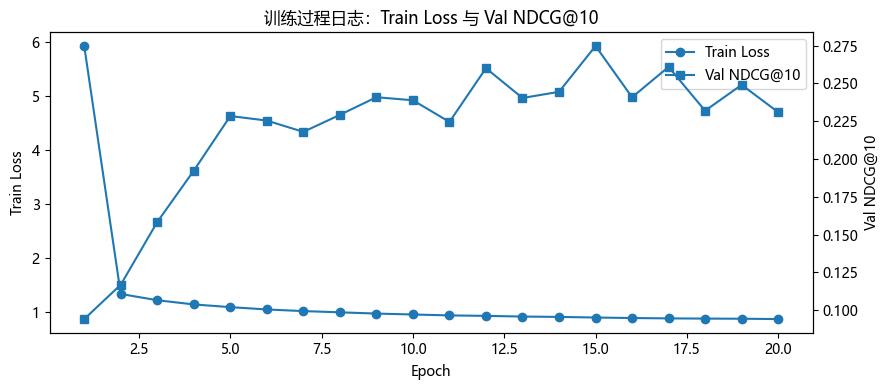


最终日志模型最佳验证 NDCG@10: 0.2748


In [14]:
# ---------- 核心输出3：训练过程日志（可选，运行时间较长） ----------
import copy
import time

MAX_EPOCHS = 50
PATIENCE = 5
TOPK_LOG = 10
VAL_USER_LIMIT = 200  # 加速日志演示，可改为 None 使用全部测试用户

val_user_ids = sorted(test_df["user_id"].unique().tolist())
if VAL_USER_LIMIT is not None:
    val_user_ids = val_user_ids[:VAL_USER_LIMIT]

val_pos_map = (
    test_df[test_df["rating"] >= 4]
    .groupby("user_id")["item_id"]
    .apply(set)
    .to_dict()
 )

def _ndcg_at_k(rel_list, k=10):
    rel = np.asarray(rel_list[:k], dtype=np.float32)
    if rel.size == 0:
        return 0.0
    discounts = 1.0 / np.log2(np.arange(2, rel.size + 2))
    dcg = float(np.sum(rel * discounts))
    ideal = np.sort(rel)[::-1]
    idcg = float(np.sum(ideal * discounts))
    return 0.0 if idcg < 1e-12 else dcg / idcg

def val_ndcg_at_k_for_model(curr_model, user_ids, top_k=10):
    curr_model.eval()
    ndcgs = []
    with torch.no_grad():
        for uid in user_ids:
            pos_items = val_pos_map.get(uid, set())
            if len(pos_items) == 0:
                continue

            seen = set(R.getrow(uid - 1).indices + 1)
            candidates = [i for i in range(1, n_items + 1) if i not in seen]
            if len(candidates) == 0:
                continue

            cand_np = np.array(candidates, dtype=np.int64)
            users_t = torch.full((len(cand_np),), uid - 1, dtype=torch.long, device=DEVICE)
            items_t = torch.tensor(cand_np - 1, dtype=torch.long, device=DEVICE)

            scores = curr_model(users_t, items_t)
            scores = torch.clamp(scores, 1.0, 5.0).cpu().numpy()
            rank = np.argsort(-scores)[:top_k]
            top_items = cand_np[rank]

            rel = [1 if item in pos_items else 0 for item in top_items]
            ndcgs.append(_ndcg_at_k(rel, k=top_k))

    return float(np.mean(ndcgs)) if len(ndcgs) > 0 else 0.0

log_model = LightMLPRec(n_users, n_items, emb_dim=32, hidden_dim=64, dropout=0.1).to(DEVICE)
log_optimizer = torch.optim.Adam(log_model.parameters(), lr=1e-3, weight_decay=1e-5)
log_criterion = nn.MSELoss()

best_state = None
best_val_ndcg = -1.0
no_improve = 0
train_log_rows = []

for epoch in range(1, MAX_EPOCHS + 1):
    log_model.train()
    running_loss = 0.0

    for users, items, ratings in train_loader:
        users = users.to(DEVICE)
        items = items.to(DEVICE)
        ratings = ratings.to(DEVICE)

        log_optimizer.zero_grad()
        out = log_model(users, items)
        loss = log_criterion(out, ratings)
        loss.backward()
        log_optimizer.step()

        running_loss += loss.item() * len(ratings)

    train_loss = running_loss / len(train_ds)
    val_ndcg = val_ndcg_at_k_for_model(log_model, val_user_ids, top_k=TOPK_LOG)

    train_log_rows.append({
        "epoch": epoch,
        "train_loss": train_loss,
        f"val_ndcg@{TOPK_LOG}": val_ndcg
    })

    print(f"Epoch {epoch:02d}/{MAX_EPOCHS}: Train Loss={train_loss:.4f}, Val NDCG@{TOPK_LOG}={val_ndcg:.4f}")

    if val_ndcg > best_val_ndcg + 1e-6:
        best_val_ndcg = val_ndcg
        best_state = copy.deepcopy(log_model.state_dict())
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch} (val NDCG no improvement for {PATIENCE} epochs)")
            break

if best_state is not None:
    log_model.load_state_dict(best_state)

train_log_df = pd.DataFrame(train_log_rows)
display(train_log_df.tail(10))

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(train_log_df["epoch"], train_log_df["train_loss"], marker="o", label="Train Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train Loss")
ax1.set_title("训练过程日志：Train Loss 与 Val NDCG@10")

ax2 = ax1.twinx()
ax2.plot(train_log_df["epoch"], train_log_df[f"val_ndcg@{TOPK_LOG}"], marker="s", label=f"Val NDCG@{TOPK_LOG}")
ax2.set_ylabel(f"Val NDCG@{TOPK_LOG}")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")
plt.tight_layout()
plt.show()

print("\n最终日志模型最佳验证 NDCG@10:", round(best_val_ndcg, 4))

## 8. 小结与教学讨论

### 本案例小结

- **ItemCF**：实现简单、可解释性强（能说明“因为你喜欢A，所以推荐B”）；
- **Light MLP**：表达能力更强，能学习更复杂的用户-物品交互；
- 实际项目中常把两者结合（召回阶段用 CF，重排阶段用神经模型）。

### 给学生的拓展与思考（附解答思路）

1. **问题：如果遇到新用户（冷启动）怎么办？**  
   思路：
   - 收集少量初始偏好（让新用户先选几部喜欢的电影）；
   - 融合内容特征（电影类型、文本简介）做内容推荐；
   - 使用热门兜底策略，逐步过渡到个性化推荐。

2. **问题：为什么离线 RMSE 变好，线上点击率不一定提高？**  
   思路：
   - RMSE 衡量的是评分预测误差，不完全等价于点击/观看行为；
   - 线上目标更偏向排序质量、多样性、新颖性；
   - 需要 A/B Test 验证真实业务指标（CTR、完播率、留存）。

3. **问题：还能如何提升 MLP 模型？**  
   思路：
   - 加入用户/电影偏置项（Bias）；
   - 增加时间特征（评分时间段）和上下文特征；
   - 用更适合排序的损失（BPR、Pairwise Loss）替代纯回归。

4. **问题：为什么推荐结果容易“头部集中”？如何缓解？**  
   思路：
   - 原因：热门电影交互数据更多，模型更容易学习到热门偏好；
   - 缓解：重排时加入多样性约束、长尾探索、流行度惩罚项。

---

> 建议同学们课后尝试：把 `u2.base/u2.test` 到 `u5.base/u5.test` 做交叉验证，对比不同划分下两种模型的稳定性。